# Analyse hydrogen market results from Pypsa-Earth network
This notebook analyze the hydrogen market data of the network (.nc) file. It generates comprehensive plots and summaries to visualize the results.
* Hydrogen Market Value
* Hydrogen Production Cost
* Hydrogen Capacity 
* Hydrogen Export 

Sources: 
- locAL DEcarbonization and HYDrogen Export: https://github.com/energyLS/aldehyde 
- Statistics module: https://pypsa.readthedocs.io/en/latest/examples/statistics.html
- Templates and colors: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/network_analysis.ipynb

File is needed:
* PyPSA network file (.nc) includes the hydrogen financing information.

## Import packages

In [2]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import os

## Path settings
This section reads the config parameters from your config.yaml file and automatically reads the output of the optimization with those settings

In [3]:
# Set your pypsa-earth directory here
PARENT = os.path.realpath("../../pypsa-earth") + "/"
# Set your network path (.nc) here
network_path = PARENT + f"results/DZA-1/postnetworks/elec_s_48_ec_lcopt_Co2L-24H_24H_2030_0.071_AB_10export.nc"
n = pypsa.Network(network_path)
statistics = n.statistics()

INFO:pypsa.io:Imported network elec_s_48_ec_lcopt_Co2L-24H_24H_2030_0.071_AB_10export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


### Hydrogen Market

In [4]:
# Hydrogen Market Value
h2_market = (statistics.loc["Link", "H2 Electrolysis"]["Market Value"]).round(2)
print(f"Yearly Hydrogen Market Value is: {h2_market} €")

Yearly Hydrogen Market Value is: 40.85 €


### Hydrogen Costs

In [5]:
h2_capex = (
        statistics.loc["Link", "H2 Electrolysis"]
        .loc["Capital Expenditure"]
        / 1e6
)  # in Mio. €
print(f"Capital Expenditure is: {h2_capex.round(2)} Mio. €")

h2_opex = (
    statistics.loc["Link", "H2 Electrolysis"]
    .loc["Operational Expenditure"]
    / 1e6
)  # in Mio. €
print(f"Operational Expenditure is: {h2_opex.round(2)} Mio. €")

hydrogen_production = (
    statistics.loc["Link", "H2 Electrolysis"]
    .loc["Supply"]
    .sum() 
    / 1e6
)  # in TWh

total_hydrogen_production_cost = h2_capex + h2_opex
hydrogen_cost_per_unit = total_hydrogen_production_cost / hydrogen_production

# Print Results
print(f"Total Hydrogen Production Cost: {total_hydrogen_production_cost.round(2)} Mio. €")
print(f"Hydrogen Production Cost per Unit: {hydrogen_cost_per_unit.round(2)} Mio. € per TWh")


Capital Expenditure is: 0.45 Mio. €
Operational Expenditure is: 0.0 Mio. €
Total Hydrogen Production Cost: 0.45 Mio. €
Hydrogen Production Cost per Unit: 42.93 Mio. € per TWh


### Hydrogen Exports

#### H2 Export on a hourly basis

<AxesSubplot:title={'center':'Hourly Hydrogen Export Prices'}, xlabel='Time', ylabel='Units: (€ / MWh)'>

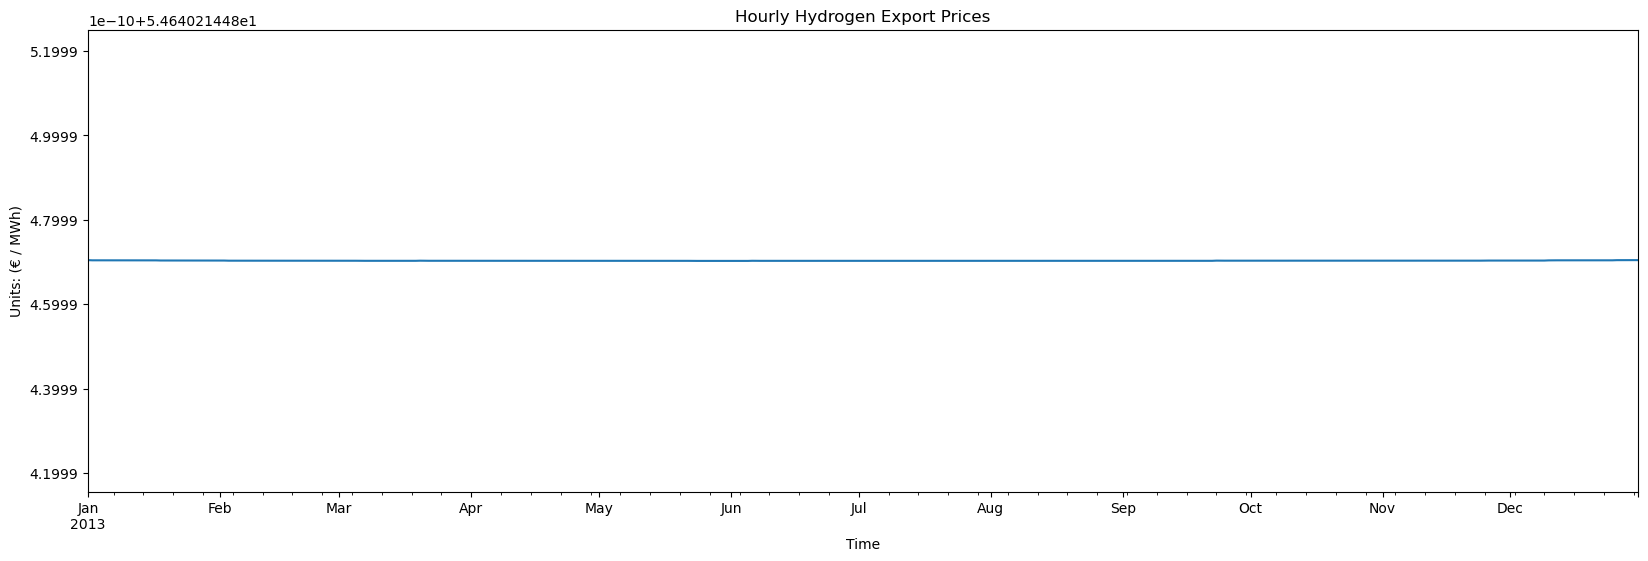

In [6]:
# Hourly hydrogen export prices
hydrogen_buses = n.buses[n.buses.index.str.contains("H2", case=False)]
hydrogen_prices = n.buses_t.marginal_price[hydrogen_buses.index]
hydrogen_export_prices = hydrogen_prices["H2 export bus"]
hydrogen_export_prices.plot(
    title="Hourly Hydrogen Export Prices",
    xlabel="Time",
    ylabel="Units: (€ / MWh)",
    figsize=(20, 6)
)

<AxesSubplot:title={'center':'Hourly Hydrogen Export Quantity'}, xlabel='Time', ylabel='Units: (MWh)'>

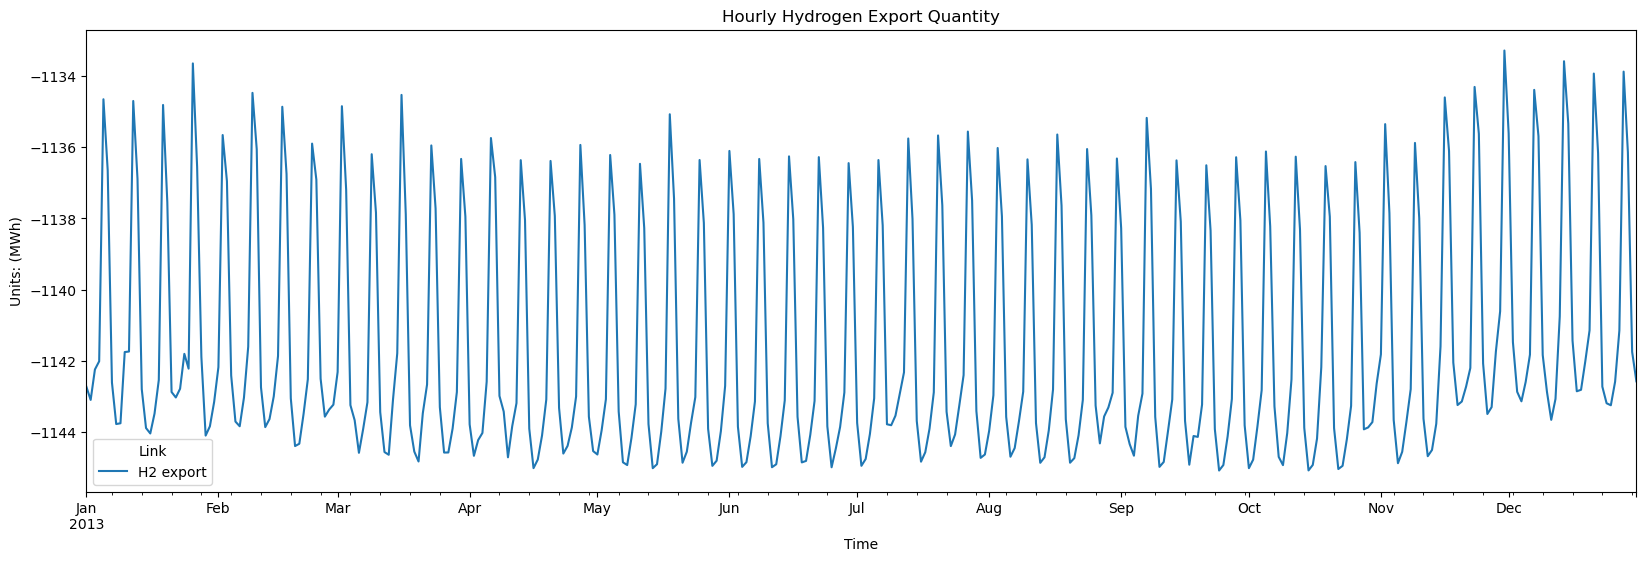

In [7]:
# Filter hydrogen export links and their quantities
hydrogen_export_links = n.links[n.links["carrier"] == "H2"]
hydrogen_export_quantity = n.links_t.p1[hydrogen_export_links.index]
hydrogen_export_quantity_cp = hydrogen_export_quantity.copy()
# Identify columns with export data dynamically (e.g., based on a naming pattern)
export_columns = [
    col for col in hydrogen_export_quantity_cp.columns if "H2 export" in col
]

# Sum the identified export columns into a new column named 'H2 export'
hydrogen_export_quantity_cp["H2 export"] = hydrogen_export_quantity_cp[export_columns].sum(axis=1)

# Drop the original separate export columns
hydrogen_export_quantity_cp = hydrogen_export_quantity_cp.drop(export_columns, axis=1)

# Plot the results
hydrogen_export_quantity_cp.plot(
    title="Hourly Hydrogen Export Quantity",
    xlabel="Time",
    ylabel="Units: (MWh)",
    figsize=(20, 6)
)

<AxesSubplot:title={'center':'Hourly Hydrogen Export Revenue'}, xlabel='Time', ylabel='Units: (€)'>

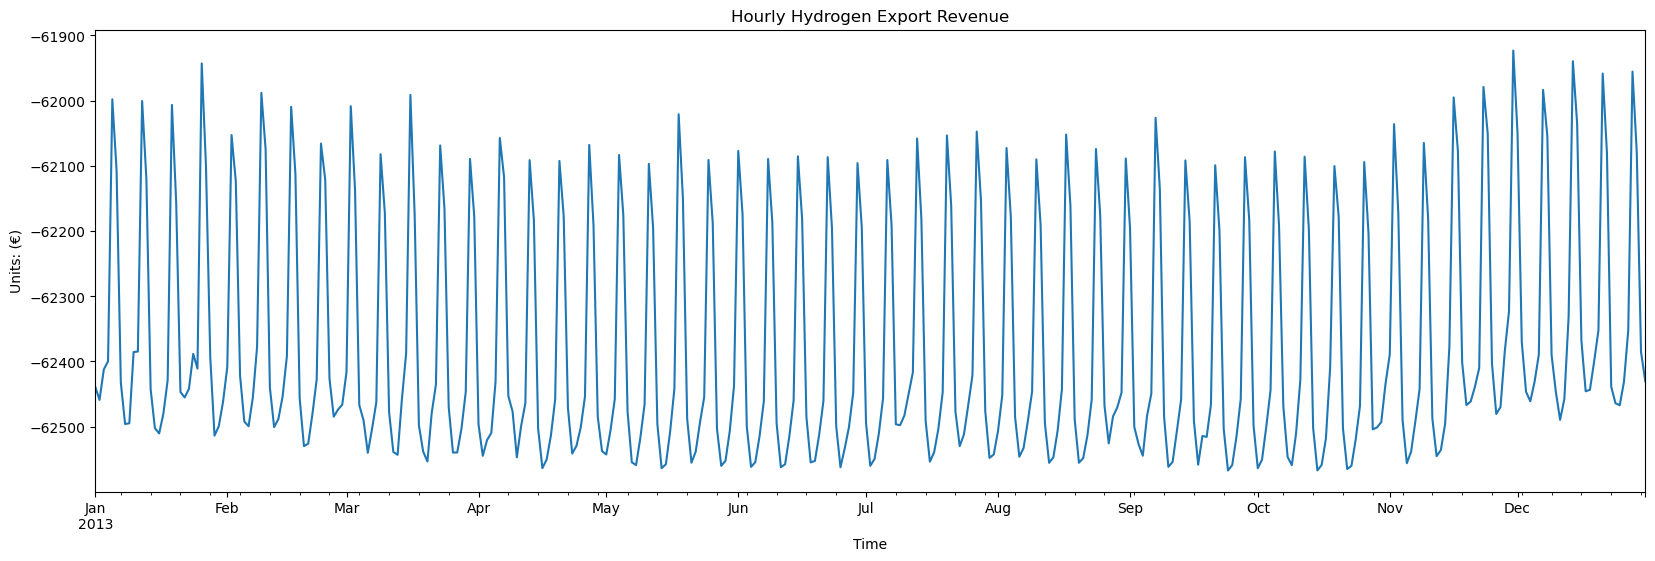

In [8]:
# Revenue
hydrogen_export_quantity.set_index(hydrogen_export_prices.index, inplace=True)
hydrogen_export_quantity_cp["Hourly Revenue"] = (
    hydrogen_export_quantity_cp["H2 export"] * hydrogen_export_prices
)

hydrogen_export_quantity_cp["Hourly Revenue"].plot(
    title="Hourly Hydrogen Export Revenue",
    xlabel="Time",
    ylabel="Units: (€)",
    figsize=(20, 6)
)

#### H2 Export on a yearly basis

In [9]:
H2_export_TWh = n.statistics.energy_balance(comps=["Load"]).loc[:,"H2"].values[0]/1e6 # in TWh
print(f"Yearly Hydrogen Export Quantity is: {H2_export_TWh} TWh")
H2_export_revenue = H2_export_TWh*h2_market
print(f"Hydrogen Export Revenue (yearly) is: {H2_export_revenue.round(2)} Mio. €")

Yearly Hydrogen Export Quantity is: -10.0 TWh
Hydrogen Export Revenue (yearly) is: -408.5 Mio. €


### Hydrogen Capacity

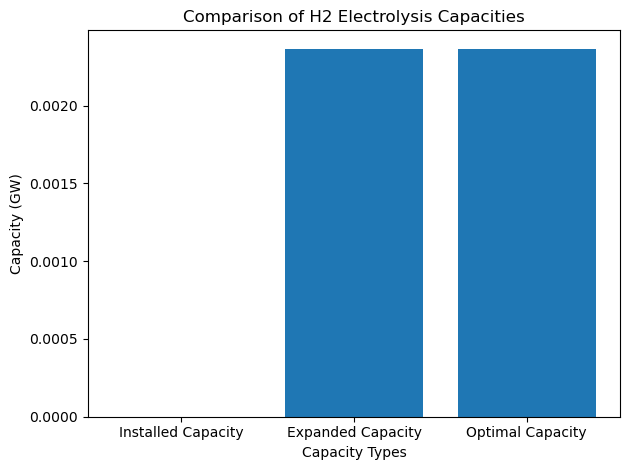

In [10]:
installed_capacity = n.statistics.installed_capacity(comps='Link').loc["H2 Electrolysis"]/ 1e3
expanded_capacity = n.statistics.expanded_capacity(comps='Link').loc["H2 Electrolysis"]/ 1e3
optimal_capacity = n.statistics.optimal_capacity(comps='Link').loc["H2 Electrolysis"]/ 1e3

categories = ['Installed Capacity', 'Expanded Capacity', 'Optimal Capacity']
values = [installed_capacity, expanded_capacity, optimal_capacity]

plt.figure()
plt.bar(categories, values)
plt.title('Comparison of H2 Electrolysis Capacities')
plt.ylabel('Capacity (GW)') 
plt.xlabel('Capacity Types')
plt.tight_layout()
plt.show()

It gets evident that only little electrolysis capacity is built. The bulk of hydrogen is produced by SMR with Carbon Capture.

``bus_carrier`` seems to be a highly relevant attribute!

In [94]:
n.statistics.supply(bus_carrier='H2') / 1e6 # TWh


component  carrier               
Link       H2                        10.000000
           H2 Electrolysis            0.010405
           H2 pipeline                0.007726
           H2 pipeline repurposed     0.147258
           SMR                        0.000839
           SMR CC                    10.250819
Store      H2                         8.739618
           H2 Store Tank              0.000476
dtype: float64

In [73]:
cap = n.statistics.optimal_capacity()
n.links.loc[n.links['carrier'] == 'SMR']

,bus0,bus1,carrier,p_nom_extendable,efficiency,capital_cost,bus2,bus3,bus4,efficiency2,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Link,,,,,,,,,,,,,,,,,,,,,
DZ.10_1_AC SMR,DZ.10_1_AC gas,DZ.10_1_AC H2,SMR,True,0.76,68192.356925,co2 atmosphere,,,0.198,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.11_1_AC SMR,DZ.11_1_AC gas,DZ.11_1_AC H2,SMR,True,0.76,68192.356925,co2 atmosphere,,,0.198,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.12_1_AC SMR,DZ.12_1_AC gas,DZ.12_1_AC H2,SMR,True,0.76,68192.356925,co2 atmosphere,,,0.198,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.13_1_AC SMR,DZ.13_1_AC gas,DZ.13_1_AC H2,SMR,True,0.76,68192.356925,co2 atmosphere,,,0.198,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.14_1_AC SMR,DZ.14_1_AC gas,DZ.14_1_AC H2,SMR,True,0.76,68192.356925,co2 atmosphere,,,0.198,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.15_1_AC SMR,DZ.15_1_AC gas,DZ.15_1_AC H2,SMR,True,0.76,68192.356925,co2 atmosphere,,,0.198,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.16_1_AC SMR,DZ.16_1_AC gas,DZ.16_1_AC H2,SMR,True,0.76,68192.356925,co2 atmosphere,,,0.198,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.17_1_AC SMR,DZ.17_1_AC gas,DZ.17_1_AC H2,SMR,True,0.76,68192.356925,co2 atmosphere,,,0.198,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ.18_1_AC SMR,DZ.18_1_AC gas,DZ.18_1_AC H2,SMR,True,0.76,68192.356925,co2 atmosphere,,,0.198,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [100]:
export_links = n.links.loc[n.links['bus1'] == 'H2 export bus'].index

<AxesSubplot:xlabel='snapshot'>

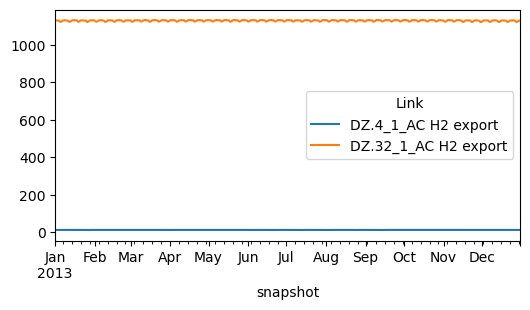

In [118]:
n.links_t.p1[export_links].abs().plot(figsize=(6,3))

In [119]:
export_bus = n.buses.loc['DZ.32_1_AC H2']

In [120]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Extract coordinates
lon, lat = export_bus['x'], export_bus['y']  # Replace with your actual values

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy([lon], [lat]), crs="EPSG:4326")

# Plot
gdf.explore()